In [ ]:
!pip install Ipython


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 50.2 MB/s eta 0:00:00


In [ ]:
from IPython.display import Image, clear_output
!pip install roboflow
clear_output()

In [ ]:
!wget -q "https://app.roboflow.com/ds/ZZX8w8khUH?key=CGeHsayFHH" -O apple-dataset.zip
!unzip -q apple-dataset.zip -d /content/apple-dataset

replace /content/apple-dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/apple-dataset/data.yaml? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/apple-dataset/README.roboflow.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: y
replace /content/apple-dataset/README.dataset.txt? [y]es, [n]o, [A]ll, [N]one, [r]ename: yes


In [ ]:
!ls -R /content/apple-dataset | head -50
!cat /content/apple-dataset/data.yaml

/content/apple-dataset:
data.yaml
README.dataset.txt
README.roboflow.txt
test
train
valid

/content/apple-dataset/test:
61OX7dhIPVL-_SL1500__jpg.rf.uxJxxVKJjZ2l4eMBkYK1.jpg
_annotations.coco.json
Apple-02_jpg.rf.WBK0HHq4Dy3Itm4oyLxL.jpg
Apple_OID_00bb5720a7ba062e_jpg.rf.E5Fkd5LPw5o4ToRVGaGF.jpg
Apple_OID_00bb5720a7ba062e_jpg.rf.qNy7GUiPRAYnZ9sCtjgB.jpg
Apple_OID_0134c9aef69c5a1b_jpg.rf.bChWA0EL85dVfEi800KV.jpg
Apple_OID_028ee4d4f435c506_jpg.rf.j9CY9zNJ2tPnigMUrkbK.jpg
Apple_OID_028ee4d4f435c506_jpg.rf.nnAc9JHA45JiVIgDFJ5t.jpg
Apple_OID_0a8a276ebeace90d_jpg.rf.KYE4E50LCYqOb8MLD5cU.jpg
Apple_OID_0b37adbec4e150a6_jpg.rf.NIzB5cwudmX5E3MMdOSv.jpg
Apple_OID_0f5afa7e7df967e5_jpg.rf.Lxb1zsLLfWRKbzA74vWI.jpg
Apple_OID_12d334ca0ef34967_jpg.rf.yqsgfv5WRrqBT49nEXZl.jpg
Apple_OID_13660879bbb1df56_jpg.rf.TLEooDJc3wyJGHcKEnAQ.jpg
Apple_OID_1fa4ba4b9e471e1d_jpg.rf.LtmCBXf7lJaXM5mgTdIm.jpg
Apple_OID_21ff3caa05a9f909_jpg.rf.MNit3nHj73VGd66mzgi2.jpg
Apple_OID_225a3b87883f9359_jpg.rf.ndSvrj9TIoRC1KIsF6de.

In [ ]:
!pip install ultralytics
clear_output()
from ultralytics import YOLO

model = YOLO('yolov8n.pt')  # COCO-pretrained nano weights

results = model.train(
    data='/content/apple-dataset/data.yaml',
    epochs=100,
    imgsz=320,          # matches our Raspberry Pi deployment target
    batch=16,
    patience=20,        # stops early if val loss plateaus
    device=0,            # GPU — make sure Runtime > GPU is enabled
    project='apple_counter',
    name='yolov8n_apple_v1',
)

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/apple-dataset/data.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=100, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=320, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=yolov8n_apple_v1-2, nbs=64,

In [ ]:
metrics = model.val()

Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 1442.7±324.6 MB/s, size: 68.7 KB)
val: Scanning /content/apple-dataset/valid/labels.cache... 100 images, 0 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 100/100 28.0Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 7/7 1.6it/s 4.4s
                   all        100        203      0.965      0.962      0.993      0.959
                     0         97        198      0.988      0.924      0.991      0.947
                     1          3          5      0.941          1      0.995      0.971
Speed: 3.1ms preprocess, 8.2ms inference, 0.0ms loss, 6.6ms postprocess per image
Results saved to /content/runs/detect/val


In [ ]:
print("mAP@0.5:", metrics.box.map50)
print("mAP@0.5:0.95:", metrics.box.map)

mAP@0.5: 0.9932133897063733
mAP@0.5:0.95: 0.9591928732115187


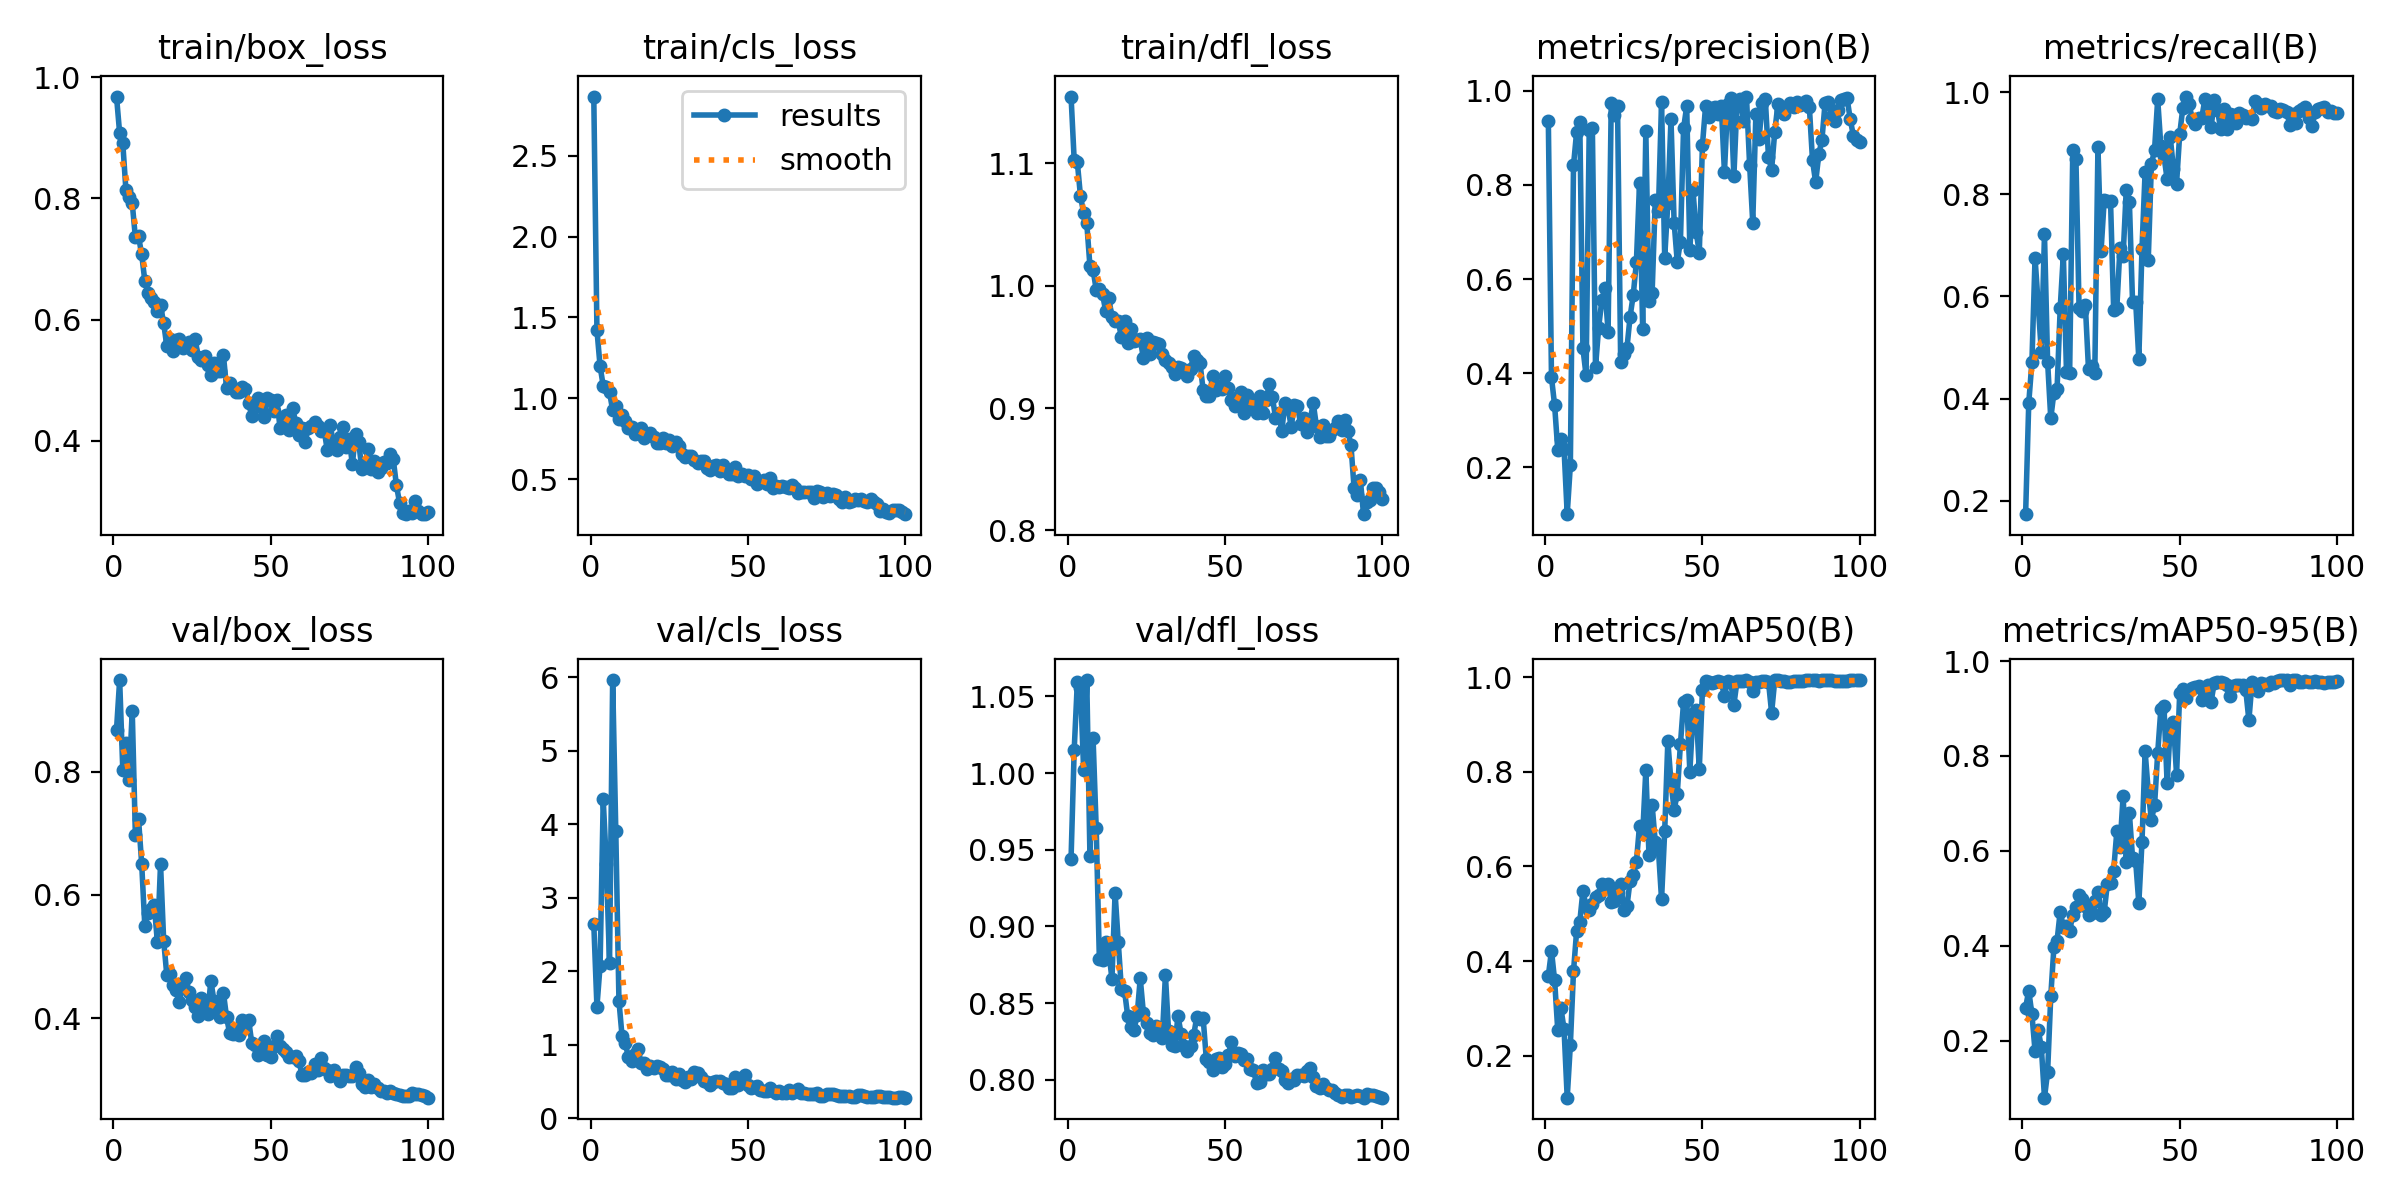

In [ ]:
from IPython.display import Image
Image('/content/runs/detect/apple_counter/yolov8n_apple_v1-2/results.png')


image 1/1 /content/apple-dataset/test/Apple_Tray_109_jpg.rf.B082V0VyZpZDwYOlgDp3.jpg: 320x320 5 0s, 9.4ms
Speed: 1.4ms preprocess, 9.4ms inference, 1.5ms postprocess per image at shape (1, 3, 320, 320)


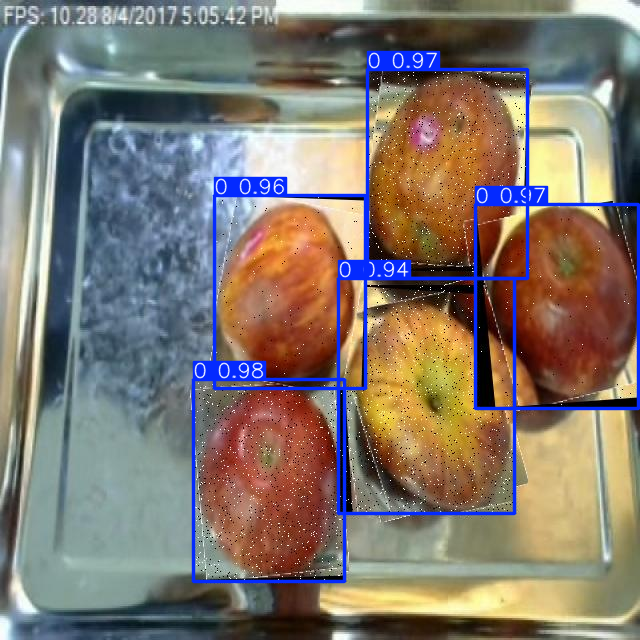

count 5


In [ ]:
result = model("/content/apple-dataset/test/Apple_Tray_109_jpg.rf.B082V0VyZpZDwYOlgDp3.jpg")
result[0].show()
print("count",len(result[0].boxes))

In [ ]:
model = YOLO("/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best.pt")
model.export(
    format = 'tflite',
    int8 = True,
    imgsz = 320,
    data = '/content/apple-dataset/data.yaml'
)

WARNING ⚠️ 'int8' is deprecated and will be removed in the future. Use 'quantize' instead.
WARNING ⚠️ format='tflite' is deprecated as of 8.4.83 and has been replaced by the unified Google LiteRT format. Exporting format='litert' instead. See https://docs.ultralytics.com/integrations/litert/
Ultralytics 8.4.115 🚀 Python-3.12.13 torch-2.11.0+cu128 CPU (Intel Xeon CPU @ 2.00GHz)
WARNING ⚠️ LiteRT INT8 export does not support end2end models, disabling end2end branch.
💡 ProTip: Export to OpenVINO format for best performance on Intel hardware. Learn more at https://docs.ultralytics.com/integrations/openvino/
Model summary (fused): 73 layers, 3,006,038 parameters, 0 gradients, 2.0 GFLOPs

PyTorch: starting from '/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best.pt' with input shape (1, 3, 320, 320) BCHW and output shape(s) (1, 6, 2100) (5.9 MB)
LiteRT: collecting INT8 calibration images from 'data=/content/apple-dataset/data.yaml'
val: Fast image access ✅ (ping: 0.0±0.0 ms, 

invalid escape sequence '\.'



LiteRT: starting export with litert_torch 0.9.3...


(00:00) [START] LiteRT-Torch Convert

(00:00) [START] LiteRT-Torch Convert > Torch Export: serving_default

...

(00:00) [ DONE] Write Model to /content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite 
(+00:00)

LiteRT: applying static quantization (int8 weights + int8 activations)...


Applying Transformations to tensors:: 100%|██████████| 413/413 [00:00<00:00, 26826.19it/s]


Model name: /content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite
Original model size: 11.62 MiB
Quantized model size: 3.16 MiB
Quantization Ratio: 0.27 (3.7x smaller)
Total time: 149.22 ms
LiteRT: export success ✅ 49.3s, saved as '/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite' (3.2 MB)

Export complete (49.4s)
Results saved to /content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite
Predict:         yolo predict task=detect model=/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite imgsz=320 
Validate:        yolo val task=detect model=/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite imgsz=320 data=/content/apple-dataset/data.yaml  
Visualize:       https://netron.app


PosixPath('/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite')

In [ ]:
!ls -lh /content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/*.tflite

-rw-r--r-- 1 root root 3.2M Aug  6 06:57 /content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite


In [ ]:
tflite_model = YOLO('/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite')
results = tflite_model('/content/test2.jpg')
print("count:", len(results[0].boxes))

Loading /content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite for LiteRT inference...

image 1/1 /content/test2.jpg: 320x320 7 0s, 36.2ms
Speed: 1.1ms preprocess, 36.2ms inference, 1.0ms postprocess per image at shape (1, 3, 320, 320)
count: 7


In [ ]:

results = tflite_model('/content/test3.jpg')
r = results[0]
print("count",len(r.boxes))



image 1/1 /content/test3.jpg: 320x320 1 0, 2 1s, 105.4ms
Speed: 5.9ms preprocess, 105.4ms inference, 4.4ms postprocess per image at shape (1, 3, 320, 320)
count 3


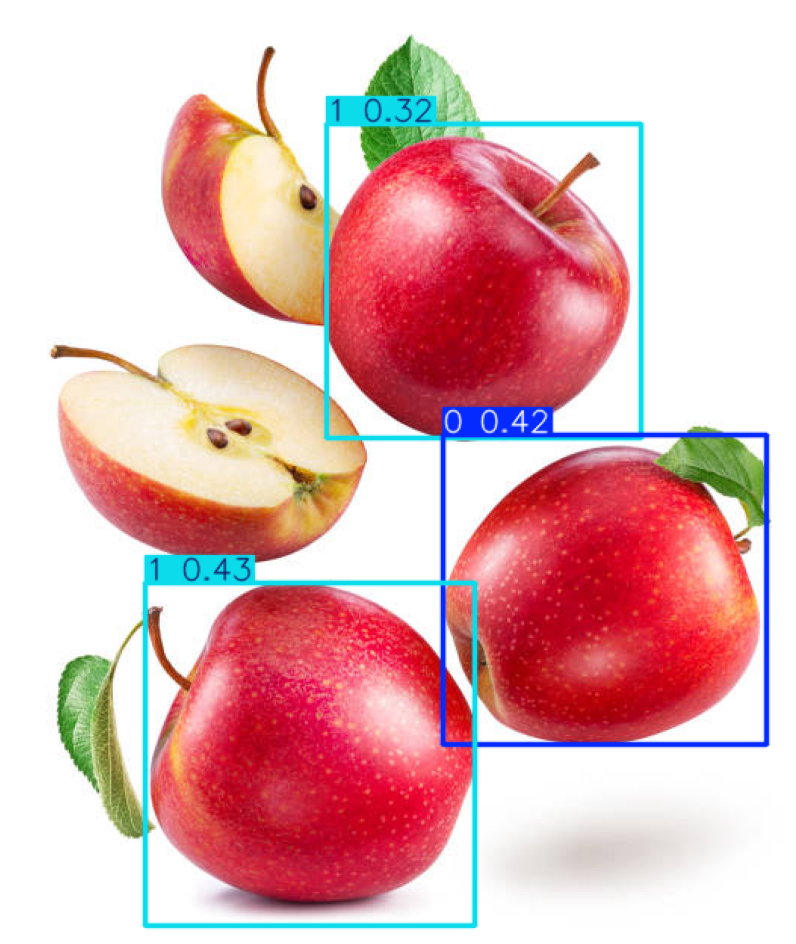

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.imshow(r.plot()[:, :, ::-1])
plt.axis('off')
plt.show()

In [ ]:
from google.colab import files
files.download('/content/runs/detect/apple_counter/yolov8n_apple_v1-2/weights/best_int8.tflite')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>